In [23]:
#Portfolio Value at Risk (VaR) & CVaR Engine - Indian Equity Market


! pip install yfinance
! pip install datetime
import pandas as pd
import numpy as np
import yfinance as yf
from scipy.stats import norm
import matplotlib.pyplot as plt
import datetime as dt


In [59]:

#DEFINE PORTFOLIO PARAMETERS & FETCH HISTORICAL DATA


tickers=['RELIANCE.NS', 'TCS.NS', 'HDFCBANK.NS', 'INFY.NS']
weights=np.array([0.25,0.25,0.25,0.25])


In [27]:
# Import the datetime module to work with date ranges
#Set the historical data start date to January 1, 2021
#Set the end date dynamically to the current date/time (today)
start=dt.datetime(2021,1,1)
#Download historical data for your tickers and extract only the "Close" prices
# Note: Ensure 'tickers' list (e.g., ['RELIANCE.NS', 'TCS.NS', ...]) is defined before runni
end= dt.datetime.now()

df=yf.download(tickers,start,end)["Close"]
df

[*********************100%***********************]  3 of 4 completed


Ticker,HDFCBANK.NS,INFY.NS,RELIANCE.NS,TCS.NS
Date,,,,
2021-01-01,663.905701,1086.097046,897.047058,2521.074463
2021-01-04,659.689453,1110.052002,898.559143,2616.811523
2021-01-05,664.674255,1114.834229,887.388367,2662.915771
2021-01-06,661.809326,1104.752563,863.986084,2627.185791
2021-01-07,659.805908,1087.562134,862.586914,2611.086426
...,...,...,...,...
2026-08-03,753.000000,1180.000000,1319.000000,2473.699951
2026-08-04,742.000000,1167.500000,1290.900024,2460.000000
2026-08-05,735.000000,1174.000000,1280.000000,2413.000000


In [29]:
# Calculate daily percentage returns (discrete simple returns) for each stock
# Mathematical Formula: R_t = (Price_t - Price_{t-1}) / Price_{t-1}

returns=df.pct_change()
returns

Ticker,HDFCBANK.NS,INFY.NS,RELIANCE.NS,TCS.NS
Date,,,,
2021-01-01,NaN,NaN,NaN,NaN
2021-01-04,-0.006351,0.022056,0.001686,0.037975
2021-01-05,0.007556,0.004308,-0.012432,0.017618
2021-01-06,-0.004310,-0.009043,-0.026372,-0.013418
2021-01-07,-0.003027,-0.015560,-0.001619,-0.006128
...,...,...,...,...
2026-08-03,0.006483,0.044155,0.008564,0.045697
2026-08-04,-0.014608,-0.010593,-0.021304,-0.005538
2026-08-05,-0.009434,0.005567,-0.008444,-0.019106


In [30]:
# Compute the daily variance-covariance matrix from asset daily returns

cov_matrix=returns.cov()
cov_matrix

Ticker,HDFCBANK.NS,INFY.NS,RELIANCE.NS,TCS.NS
Ticker,,,,
HDFCBANK.NS,0.000187,0.000054,0.000073,0.000044
INFY.NS,0.000054,0.000254,0.000059,0.000162
RELIANCE.NS,0.000073,0.000059,0.000206,0.000054
TCS.NS,0.000044,0.000162,0.000054,0.000198


In [31]:
# Calculate the average (mean) daily return for each individual asset
# Mathematical Formula for stock i: mu_i = (sum of daily returns) / (total number of trading days)

avg_returns=returns.mean()
avg_returns

Ticker
HDFCBANK.NS    0.000163
INFY.NS        0.000184
RELIANCE.NS    0.000390
TCS.NS         0.000079
dtype: float64

In [34]:
count=len(returns)
count

1387

In [44]:

# 3. Calculate portfolio mean and std
port_mean = avg_returns @ weights
port_std = np.sqrt(weights.T @ cov_matrix @ weights)


In [45]:
port_mean

np.float64(0.00041303076982218754)

In [46]:
port_std

np.float64(0.010008606663709273)

<function matplotlib.pyplot.show(close=None, block=None)>

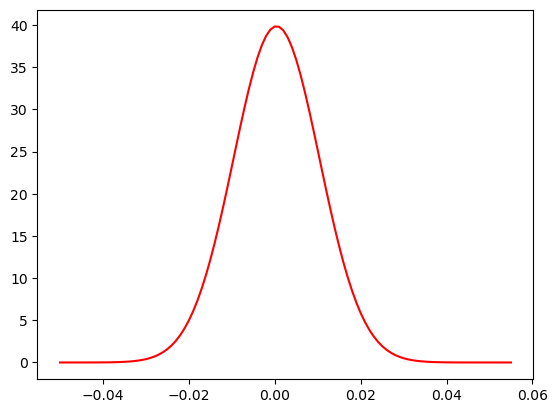

In [50]:
#  Create an array of return values ranging from -5% (-0.05) to +5.5% (+0.055) in increments of 0.1% (0.001)
# This represents the X-axis (range of potential daily portfolio returns)
# Calculate the theoretical Probability Density Function (PDF) of the Normal Distribution
# Parametric Assumption: Assumes portfolio returns follow N(port_mean, port_std^2)
x=np.arange(-0.05,0.055,0.001)
norm_distn=norm.pdf(x,port_mean,port_std)

plt.plot(x,norm_distn,color="r")
plt.show



In [60]:
# Set the significance level (alpha) to 0.05 (corresponds to a 95% Confidence Level)

confidence_level=0.05

VaR=norm.ppf(confidence_level,port_mean,port_std)
VaR

np.float64(0.01687572374135506)

In [56]:
# Calculate the lower bound of the 95% Confidence Interval for expected daily mean return
# Formula: Mean - (2 * Standard Error), where Standard Error = Volatility / sqrt(Sample Size

# Calculate the upper bound of the 95% Confidence Interval for expected daily mean return
# Formula: Mean + (2 * Standard Error)


lower= port_mean-2*port_std/np.sqrt(count)
higher= port_mean+2*port_std/np.sqrt(count)

In [62]:
lower

np.float64(-0.0001244530401621031)

In [61]:
higher

np.float64(0.0009505145798064782)